In [12]:
from helpers.load import *
from helpers.select_scenario import select_scenario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [13]:
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'freshwater' / 'nodeXCount=10_nodeXSpacing=20_nodeYCount=10_nodeYSpacing=20_uavSpeed=5_propagationModel=freshwater'
scenario_folder_freshwater = Path(os.path.abspath('')) / 'logs' / 'unified' / 'air' / 'nodeXCount=10_nodeXSpacing=20_nodeYCount=10_nodeYSpacing=20_uavSpeed=5_propagationModel=air'

In [14]:
packet_logging_stats_freshwater  = load_packet_logging_stats(scenario_folder_freshwater)
packet_logging_stats_air  = load_packet_logging_stats(scenario_folder_air)

FileNotFoundError: [Errno 2] No such file or directory: '/home/research/ns3/postprocessing/logs/unified/air/nodeXCount=10_nodeXSpacing=20_nodeYCount=10_nodeYSpacing=20_uavSpeed=5_propagationModel=air/PacketLoggingStats.csv'

In [ ]:
# Drop all packets with a ReceiverNodeId or SenderNodeId of (uint32_t) -1 aka 4294967295 (unknown nodes, maybe broadcast/discovery signals?)
packet_logging_stats_freshwater = packet_logging_stats_freshwater[~packet_logging_stats_freshwater['ReceiverNodeId'].isin([-1, 4294967295])]
packet_logging_stats_freshwater['Distance'] = np.sqrt((packet_logging_stats_freshwater['SourceNodeX'] - packet_logging_stats_freshwater['DestinationNodeX'])**2 + (packet_logging_stats_freshwater['SourceNodeY'] - packet_logging_stats_freshwater['DestinationNodeY'])**2 + (packet_logging_stats_freshwater['SourceNodeZ'] - packet_logging_stats_freshwater['DestinationNodeZ'])**2)
packet_logging_stats_freshwater['AirTime'] = packet_logging_stats_freshwater['RxEndLastSeen'] - packet_logging_stats_freshwater['TxBeginFirstSeen']

# Drop all packets with a ReceiverNodeId or SenderNodeId of (uint32_t) -1 aka 4294967295 (unknown nodes, maybe broadcast/discovery signals?)
packet_logging_stats_air = packet_logging_stats_air[~packet_logging_stats_air['ReceiverNodeId'].isin([-1, 4294967295])]
packet_logging_stats_air['Distance'] = np.sqrt((packet_logging_stats_air['SourceNodeX'] - packet_logging_stats_air['DestinationNodeX'])**2 + (packet_logging_stats_air['SourceNodeY'] - packet_logging_stats_air['DestinationNodeY'])**2 + (packet_logging_stats_air['SourceNodeZ'] - packet_logging_stats_air['DestinationNodeZ'])**2)
packet_logging_stats_air['AirTime'] = packet_logging_stats_air['RxEndLastSeen'] - packet_logging_stats_air['TxBeginFirstSeen']

,PacketId,PacketSize,ReceiverMac,ReceiverNodeId,ReceiverNodeType,TransmitterMac,TransmitterNodeId,TransmitterNodeType,DestinationMac,DestinationNodeId,...,RxDropCount,SourceNodeX,SourceNodeY,SourceNodeZ,DestinationNodeX,DestinationNodeY,DestinationNodeZ,LastRxSignal,Distance,AirTime
5,5,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,1280029.0
6,6,75,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1.0,...,0,0.0,20.0,0.0,0.0,20.000000,-1.0,-51.3440,1.000000,1080029.0
14,15,94,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,1200029.0
15,19,94,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1.0,...,0,0.0,20.0,0.0,0.0,20.000000,-1.0,-51.3440,1.000000,1200029.0
18,22,90,00:00:00:00:00:06,5,AP,00:00:00:00:00:02,1,STA,00:00:00:00:00:06,5.0,...,0,0.0,20.0,-1.0,0.0,20.000000,0.0,-67.3440,1.000000,1200029.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70963,256580,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:01,0,STA,00:00:00:00:00:06,5.0,...,1,0.0,0.0,-1.0,0.0,0.008110,0.0,-67.3456,1.000033,5358029.0
70972,256616,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:05,4,STA,00:00:00:00:00:06,5.0,...,0,0.0,0.0,0.0,0.0,0.005355,0.0,15.5271,0.005355,1280000.0
70973,256617,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:01,0,STA,00:00:00:00:00:06,5.0,...,1,0.0,0.0,-1.0,0.0,0.005332,0.0,-67.3447,1.000014,5462029.0
70982,256653,102,00:00:00:00:00:06,5,AP,00:00:00:00:00:05,4,STA,00:00:00:00:00:06,5.0,...,0,0.0,0.0,0.0,0.0,0.002578,0.0,16.9026,0.002578,1280000.0


In [ ]:
# Group the packet_stats_freshwater by Distance. Then calculate the average throughput by dividing the sum of the packet sizes by the sum of the AirTime
def calculate_throughput(packet_stats_df):
    throughput_df = packet_stats_df[
            (packet_stats_df['SourceNodeType'] == 'STA') & 
            (packet_stats_df['DestinationNodeType'] == 'AP') #&
            #(packet_stats_df['PacketSize'] >= 150)  # Filter out handshake/ACK packets
        ].groupby('Distance').agg({
            'PacketSize': 'mean', 
            'AirTime': 'mean',
            'PacketId': 'count'
        })
    # Convert AirTime from ns to s
    throughput_df['AirTime'] = throughput_df['AirTime'] / 1e9
    throughput_df['Throughput'] = throughput_df['PacketSize'] / throughput_df['AirTime']
    return throughput_df

throughput_freshwater = calculate_throughput(packet_logging_stats_freshwater)
throughput_air = calculate_throughput(packet_logging_stats_air)
throughput_freshwater.head(30)

,PacketSize,AirTime,PacketId,Throughput
Distance,,,,
0.002578,102.0,0.00128,1,79687.5
0.002588,102.0,0.00128,1,79687.5
0.002595,102.0,0.00128,1,79687.5
0.002607,102.0,0.00128,1,79687.5
0.002613,102.0,0.00128,1,79687.5
0.002631,102.0,0.00128,1,79687.5
0.002667,102.0,0.00128,1,79687.5
0.002686,102.0,0.00128,1,79687.5
0.002723,102.0,0.00128,1,79687.5


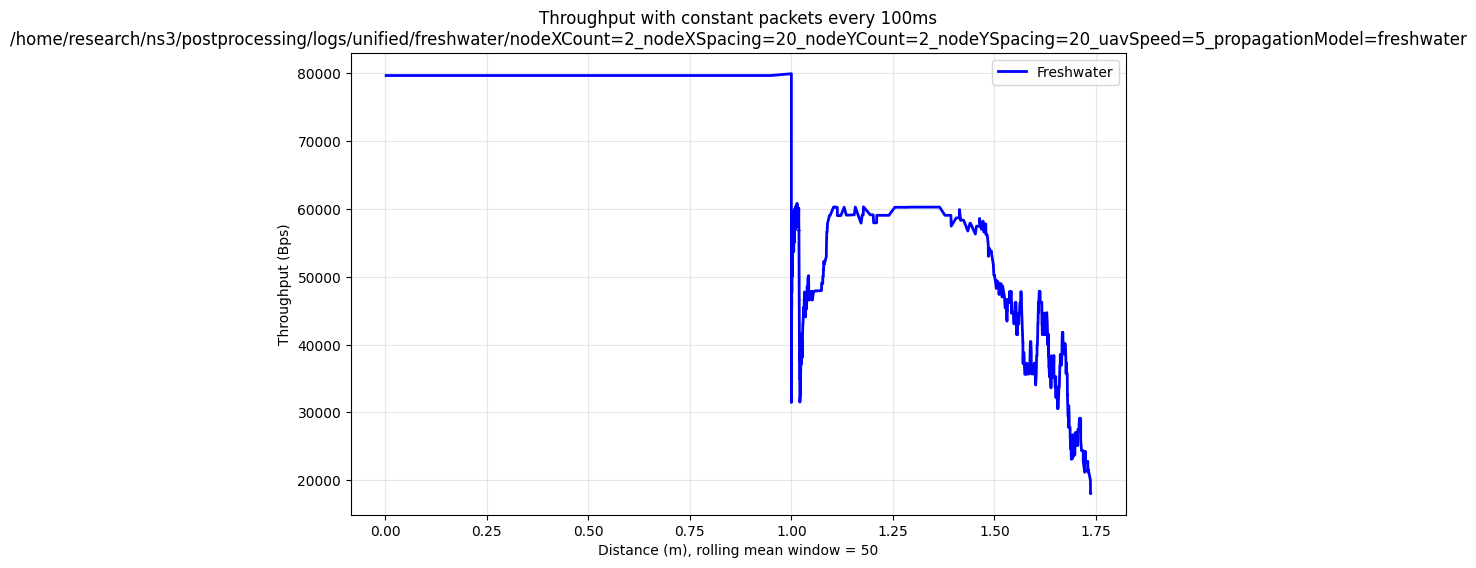

In [ ]:
rolling_mean_window_size = 50
plt.figure(figsize=(10, 6))

# Plot rolling averages as solid lines
plt.plot(throughput_freshwater.index, throughput_freshwater['Throughput'].rolling(window=rolling_mean_window_size, min_periods=1).mean(), 
         label='Freshwater', color='blue', linewidth=2)
plt.plot(throughput_air.index, throughput_air['Throughput'].rolling(window=rolling_mean_window_size, min_periods=1).mean(), 
         label='Air', color='green', linewidth=2)

plt.xlabel(f'Distance (m), rolling mean window = {rolling_mean_window_size}')
plt.ylabel('Throughput (Bps)')
plt.title(f'Throughput with constant packets every 100ms\n{scenario_folder_freshwater}')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()